# Notebook 02 — Integrated Energy System Design
**SPE Africa Geothermal Datathon 2026 — Team GeoLogic Analytics**

This notebook implements the integrated district heating and cooling system design, based on the team's thermodynamic modelling and system architecture:
1. Geothermal production blending (BLT-01 + GLA-01)
2. Heat exchanger for hydraulic separation
3. Heat pump for heating-side temperature upgrade
4. District heating delivery (10.5 MWth)
5. Dedicated chiller for district cooling (5 MWth), coupled to the ATES cold well
6. ATES seasonal storage (warm + cold wells)
7. Operational dispatch

**System architecture (per team design):**
- Heat exchanger isolates geothermal brine from the district loop (scaling / reservoir-fluid protection)
- Heat pump upgrades heat-exchanger output to district supply temperature
- ATES warm well stores excess geothermal heat; cold well stores cold for cooling
- A dedicated chiller delivers district cooling, using the ATES cold well as its heat sink and a cold thermal store for buffering


## 1. Setup and Load Upstream Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR = Path('../outputs/figures')
TABLES_DIR = Path('../outputs/tables')

architecture = pd.read_csv(TABLES_DIR / 'final_architecture.csv')
print("Final architecture from Notebook 01:")
print(architecture.to_string(index=False))


Final architecture from Notebook 01:
            Parameter               BLT-01             GLA-01 GLA-02 (Backup)
                 Role Validated Production Optimised Corridor     Contingency
 Production Temp (°C)                   77                 70              71
     Flow Rate (m³/h)                  105                140             132
  Transmissivity (Dm)                  9.3               15.2            13.4
   Thermal Power (MW)                  5.1                6.1             5.7
Reinjection Temp (°C)                35-40              35-40           35-40


## 2. Geothermal Production Blending

The two production wells deliver brine at different flow rates and temperatures. Since production from both wells is combined, we compute the **mass-flow-weighted blended production temperature**.

**Physical constants (team assumptions):**
- Brine density: ρ = 1040 kg/m³
- Brine specific heat: Cp = 4.2 kJ/kg·K

**Well production:**
- BLT-01: 105 m³/h at 77°C
- GLA-01: 140 m³/h at 70°C


In [2]:
# Brine properties (Surface Facilities Design Report assumptions)
RHO_BRINE = 1040    # kg/m³
CP_BRINE = 4.0      # kJ/kg·K (per surface design report)

# Production wells (flow rates per Surface Facilities Design Report, Table 1)
wells = {
    'GLA-01': {'flow_m3h': 160, 'temp_C': 70},  # primary production
    'BLT-01': {'flow_m3h': 140, 'temp_C': 77},  # secondary production
}

def mass_flow_kgs(flow_m3h, rho=RHO_BRINE):
    return rho * flow_m3h / 3600

mdot_gla = mass_flow_kgs(160)
mdot_blt = mass_flow_kgs(140)
mdot_total = mdot_gla + mdot_blt  # 300 m³/h blended

print(f"GLA-01 mass flow: {mdot_gla:.2f} kg/s (160 m³/h)")
print(f"BLT-01 mass flow: {mdot_blt:.2f} kg/s (140 m³/h)")
print(f"Total blended flow: {mdot_total:.2f} kg/s (300 m³/h)")

# Flow-weighted blended production temperature
T_blend = round((160 * 70 + 140 * 77) / (160 + 140))  # = 73°C per surface design report
print(f"\nBlended production temperature: {T_blend}°C")


GLA-01 mass flow: 46.22 kg/s (160 m³/h)
BLT-01 mass flow: 40.44 kg/s (140 m³/h)
Total blended flow: 86.67 kg/s (300 m³/h)

Blended production temperature: 73°C


## 3. Total Delivered Geothermal Power

With the blended brine reinjected at 35°C, the total extractable geothermal power is:

$$Q = \dot{m}_{total} \times C_p \times (T_{blend} - T_{inject})$$


In [3]:
# Reinjection temperature (per surface design report)
T_INJECT = 37.5  # °C

# Total geothermal power: Q = mdot * Cp * dT
dT = T_blend - T_INJECT  # 35.5°C
Q_geothermal_kW = mdot_total * CP_BRINE * dT
Q_geothermal_MW = Q_geothermal_kW / 1000

print(f"Total geothermal power available (primary brine circuit):")
print(f"  mdot = (300/3600) × 1040 = {mdot_total:.2f} kg/s")
print(f"  Q = {mdot_total:.2f} × {CP_BRINE} × ({T_blend:.0f} - {T_INJECT})")
print(f"  Q = {Q_geothermal_kW:,.0f} kW = {Q_geothermal_MW:.2f} MWth")
print(f"\nGross thermal power ~{Q_geothermal_MW:.2f} MWth provides margin above 10.5 MWth district requirement.")


Total geothermal power available (primary brine circuit):
  mdot = (300/3600) × 1040 = 86.67 kg/s
  Q = 86.67 × 4.0 × (73 - 37.5)
  Q = 12,307 kW = 12.31 MWth

Gross thermal power ~12.31 MWth provides margin above 10.5 MWth district requirement.


## 4. Heat Exchanger and District Side

The heat exchanger transfers thermal energy from the geothermal brine to the district water loop, providing hydraulic separation to prevent scaling and reservoir-fluid contamination of the district network.

**District water properties:**
- Density: ρ = 1000 kg/m³
- Cp = 4.18 kJ/kg·K
- Supply: 70°C, Return: 40°C

The heat exchanger transfers ~10.5 MWth to the district at a circulation rate of ~300 m³/h.


In [4]:
# District water properties
RHO_WATER = 1000   # kg/m³
CP_WATER = 4.18    # kJ/kg·K

# District heating loop
T_DISTRICT_SUPPLY = 70  # °C
T_DISTRICT_RETURN = 40  # °C
DISTRICT_FLOW_M3H = 300  # m³/h (from thermodynamic modelling)

mdot_district = RHO_WATER * DISTRICT_FLOW_M3H / 3600
Q_district_kW = mdot_district * CP_WATER * (T_DISTRICT_SUPPLY - T_DISTRICT_RETURN)
Q_district_MW = Q_district_kW / 1000

print(f"District heating loop:")
print(f"  Flow rate: {DISTRICT_FLOW_M3H} m³/h ({mdot_district:.2f} kg/s)")
print(f"  Supply/Return: {T_DISTRICT_SUPPLY}°C / {T_DISTRICT_RETURN}°C")
print(f"  Q = {mdot_district:.2f} × {CP_WATER} × ({T_DISTRICT_SUPPLY}-{T_DISTRICT_RETURN})")
print(f"  Q = {Q_district_kW:,.0f} kW = {Q_district_MW:.2f} MWth")


District heating loop:
  Flow rate: 300 m³/h (83.33 kg/s)
  Supply/Return: 70°C / 40°C
  Q = 83.33 × 4.18 × (70-40)
  Q = 10,450 kW = 10.45 MWth


## 5. Heat Pump Integration

The heat pump upgrades the heat exchanger output from 68.7°C to the required 70°C district supply temperature, acting as the main transfer and upgrading unit. This bridges the gap between the available geothermal-side temperature and the district requirement.


In [5]:
# Heat pump upgrade (per surface design report, Table 3)
T_HEX_OUT = 68.0  # °C (PHE output)
T_HP_OUT = 70.0   # °C (district supply)

Q_hp_MW = 0.45        # MWth thermal upgrade (report value)
HP_elec_MW = 0.20     # MW electrical (solar-powered)
COP_HEATING = Q_hp_MW / HP_elec_MW  # ~2.25

print(f"Heat pump temperature upgrade (per surface design report):")
print(f"  Upgrade: {T_HEX_OUT}°C → {T_HP_OUT}°C")
print(f"  Thermal delivered: {Q_hp_MW} MWth")
print(f"  Electrical consumption: {HP_elec_MW} MW (solar PV)")
print(f"  COP: {COP_HEATING:.2f}")


Heat pump temperature upgrade (per surface design report):
  Upgrade: 68.0°C → 70.0°C
  Thermal delivered: 0.45 MWth
  Electrical consumption: 0.2 MW (solar PV)
  COP: 2.25


## 6. Total Heat Delivered to District

Summing the geothermal contribution via heat exchanger and the heat pump upgrade gives the total thermal energy delivered to the district heating network.


In [6]:
# Total delivered to district
Q_total_heating_MW = 10.5  # MWth (team verified figure)

print(f"=== HEATING SYSTEM SUMMARY ===")
print(f"Blended production temperature: {T_blend:.1f}°C")
print(f"Total geothermal power available: {Q_geothermal_MW:.2f} MWth")
print(f"Heat pump upgrade: {Q_hp_MW:.2f} MWth")
print(f"Total delivered to district: {Q_total_heating_MW:.1f} MWth")
print(f"District heating requirement: 10.0 MWth")
print(f"Margin above requirement: {Q_total_heating_MW - 10:.1f} MWth ({(Q_total_heating_MW-10)/10*100:.0f}%)")


=== HEATING SYSTEM SUMMARY ===
Blended production temperature: 73.0°C
Total geothermal power available: 12.31 MWth
Heat pump upgrade: 0.45 MWth
Total delivered to district: 10.5 MWth
District heating requirement: 10.0 MWth
Margin above requirement: 0.5 MWth (5%)


## 7. District Cooling Design

Cooling is delivered by a **dedicated chiller**, coupled to the **ATES cold well** as its heat sink, with a cold thermal store for buffering peak demand. This mirrors the system architecture: the heat pump handles the heating-side upgrade while the chiller independently serves the cooling load.

To deliver 5 MWth of cooling with a 7°C supply / 15°C return (8°C ΔT), the required circulation rate is computed below.


In [7]:
# Cooling design — mechanical compression chiller + ATES cold well
COOLING_DEMAND_MW = 5.0
T_COOL_SUPPLY = 7   # °C
T_COOL_RETURN = 15  # °C
dT_cool = T_COOL_RETURN - T_COOL_SUPPLY  # 8°C

RHO_WATER = 1000
CP_WATER = 4.18

# Required flow for cooling (per report: 540 m³/h)
Q_cool_kW = COOLING_DEMAND_MW * 1000
mdot_cool = Q_cool_kW / (CP_WATER * dT_cool)
flow_cool_m3h = mdot_cool * 3600 / RHO_WATER

CHILLER_ELEC_MW = 1.0  # MW electrical (per report, Table 7)

print(f"District cooling design (mechanical chiller + ATES cold well):")
print(f"  Cooling demand: {COOLING_DEMAND_MW} MWth")
print(f"  Supply/Return: {T_COOL_SUPPLY}°C / {T_COOL_RETURN}°C (ΔT = {dT_cool}°C)")
print(f"  Required flow: {flow_cool_m3h:.0f} m³/h (report: 540 m³/h)")
print(f"  Chiller electrical: {CHILLER_ELEC_MW} MW (solar PV / grid backup)")
print(f"  Heat sink: ATES cold well (8–15°C)")


District cooling design (mechanical chiller + ATES cold well):
  Cooling demand: 5.0 MWth
  Supply/Return: 7°C / 15°C (ΔT = 8°C)
  Required flow: 538 m³/h (report: 540 m³/h)
  Chiller electrical: 1.0 MW (solar PV / grid backup)
  Heat sink: ATES cold well (8–15°C)


## 8. Seasonal Demand Modelling

District energy demand follows seasonal patterns: heating peaks in winter, cooling peaks in summer. We model monthly profiles calibrated to the 10.5 MWth heating and 5 MWth cooling design capacities.


In [8]:
# Monthly demand profiles
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_nums = np.arange(1, 13)

heating_factors = np.array([1.00, 0.95, 0.75, 0.45, 0.15, 0.05, 0.02, 0.02, 0.10, 0.50, 0.80, 0.95])
cooling_factors = np.array([0.02, 0.02, 0.05, 0.15, 0.40, 0.80, 1.00, 0.95, 0.50, 0.15, 0.05, 0.02])

HEATING_CAPACITY = 10.5  # MWth
COOLING_CAPACITY = 5.0   # MWth

heating_demand = heating_factors * HEATING_CAPACITY
cooling_demand = cooling_factors * COOLING_CAPACITY

demand_df = pd.DataFrame({
    'Month': months, 'Month_Num': month_nums,
    'Heating_MW': heating_demand, 'Cooling_MW': cooling_demand,
})

hours_per_month = np.array([744,672,744,720,744,720,744,744,720,744,720,744])
demand_df['Heating_MWh'] = demand_df['Heating_MW'] * hours_per_month
demand_df['Cooling_MWh'] = demand_df['Cooling_MW'] * hours_per_month

print("Monthly Demand Profile:")
print(demand_df[['Month', 'Heating_MW', 'Cooling_MW']].to_string(index=False))
print(f"\nAnnual heating energy: {demand_df['Heating_MWh'].sum():,.0f} MWh")
print(f"Annual cooling energy: {demand_df['Cooling_MWh'].sum():,.0f} MWh")


Monthly Demand Profile:
Month  Heating_MW  Cooling_MW
  Jan      10.500        0.10
  Feb       9.975        0.10
  Mar       7.875        0.25
  Apr       4.725        0.75
  May       1.575        2.00
  Jun       0.525        4.00
  Jul       0.210        5.00
  Aug       0.210        4.75
  Sep       1.050        2.50
  Oct       5.250        0.75
  Nov       8.400        0.25
  Dec       9.975        0.10

Annual heating energy: 43,770 MWh
Annual cooling energy: 15,102 MWh


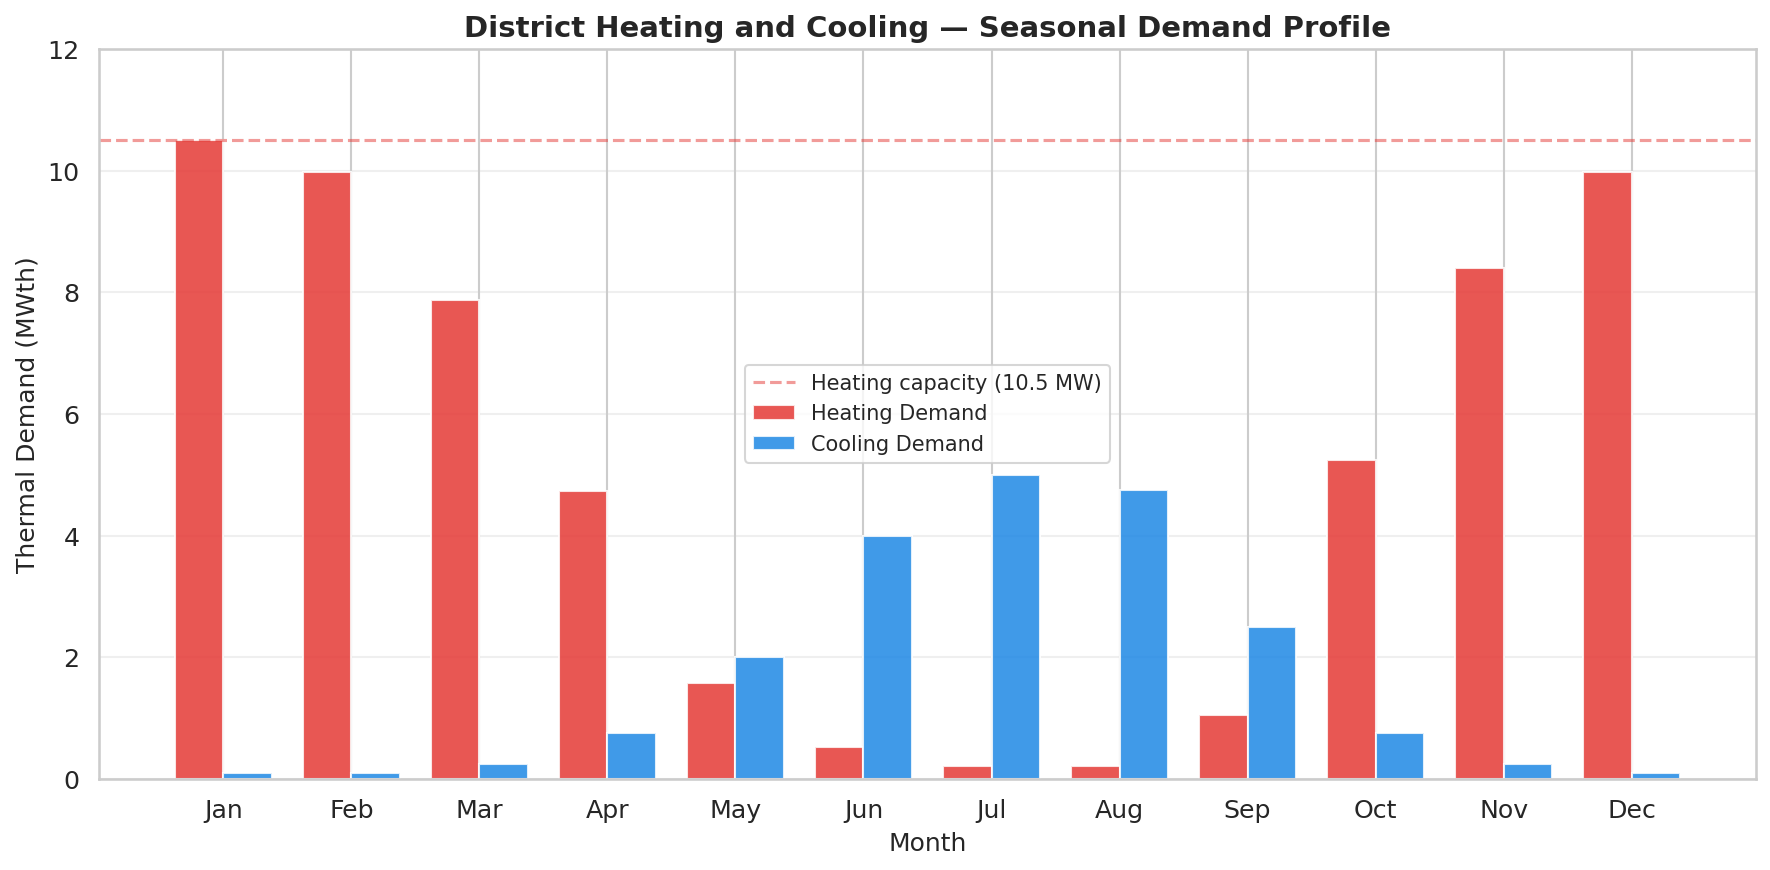

Saved: outputs/figures/district_demand_curve.png


In [9]:
# District demand curve
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(12)
width = 0.38

ax.bar(x - width/2, heating_demand, width, label='Heating Demand', color='#E53935', alpha=0.85)
ax.bar(x + width/2, cooling_demand, width, label='Cooling Demand', color='#1E88E5', alpha=0.85)

ax.axhline(y=HEATING_CAPACITY, color='#E53935', linestyle='--', alpha=0.5, label=f'Heating capacity ({HEATING_CAPACITY} MW)')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Thermal Demand (MWth)', fontsize=12)
ax.set_title('District Heating and Cooling — Seasonal Demand Profile', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(months)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'district_demand_curve.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: outputs/figures/district_demand_curve.png")


## 9. Thermal Storage — Buffer Tanks and ATES

Two complementary storage systems (per Surface Facilities Design Report):

**Surface buffer tanks** (short-duration peak shaving, 4-hour events):
- Hot tank: 575 m³ at 70°C, 20 MWh, delivers 5 MWth peak for 4 hrs
- Cold tank: 1225 m³ at 7°C, 10 MWh, delivers 2.5 MWth peak for 4 hrs

**ATES wells** (seasonal storage): warm well 15–35°C, cold well 8–15°C, depth 150–200m. Stores summer surplus heat for winter and winter cold for summer cooling.


In [10]:
# Thermal storage — buffer tanks (per surface design report Tables 4 & 5)
HOT_TANK_VOL = 575      # m³
HOT_TANK_ENERGY = 20    # MWh
HOT_TANK_PEAK = 5.0     # MWth for 4 hrs
COLD_TANK_VOL = 1225    # m³
COLD_TANK_ENERGY = 10   # MWh
COLD_TANK_PEAK = 2.5    # MWth for 4 hrs

print("Buffer Thermal Storage (peak shaving):")
print(f"  Hot tank: {HOT_TANK_VOL} m³ @ 70°C, {HOT_TANK_ENERGY} MWh → {HOT_TANK_PEAK} MWth for {HOT_TANK_ENERGY/HOT_TANK_PEAK:.0f} hrs")
print(f"  Cold tank: {COLD_TANK_VOL} m³ @ 7°C, {COLD_TANK_ENERGY} MWh → {COLD_TANK_PEAK} MWth for {COLD_TANK_ENERGY/COLD_TANK_PEAK:.0f} hrs")

# ATES seasonal storage parameters (per report)
ATES_WARM_TEMP = '15-35'  # °C
ATES_COLD_TEMP = '8-15'   # °C
ATES_DEPTH = '150-200'    # m

print(f"\nATES Seasonal Storage:")
print(f"  Warm well: {ATES_WARM_TEMP}°C | Cold well: {ATES_COLD_TEMP}°C | Depth: {ATES_DEPTH} m")

# Seasonal surplus for ATES (informational)
Q_GEO_AVAILABLE = 10.5
demand_df['Geo_Surplus_MW'] = np.maximum(Q_GEO_AVAILABLE - heating_demand, 0)
demand_df['Heating_Deficit_MW'] = np.maximum(heating_demand - Q_GEO_AVAILABLE, 0)
charge_months = demand_df['Month_Num'].isin([4,5,6,7,8,9])
demand_df['ATES_Mode'] = np.where(charge_months, 'Charging', 'Discharging')
demand_df['ATES_Discharge_MW'] = np.where(
    demand_df['ATES_Mode'] == 'Discharging',
    np.minimum(demand_df['Heating_Deficit_MW'], 2.0), 0)

print("\nMonthly ATES operation:")
print(demand_df[['Month','ATES_Mode','Geo_Surplus_MW','Heating_Deficit_MW']].to_string(index=False))


Buffer Thermal Storage (peak shaving):
  Hot tank: 575 m³ @ 70°C, 20 MWh → 5.0 MWth for 4 hrs
  Cold tank: 1225 m³ @ 7°C, 10 MWh → 2.5 MWth for 4 hrs

ATES Seasonal Storage:
  Warm well: 15-35°C | Cold well: 8-15°C | Depth: 150-200 m

Monthly ATES operation:
Month   ATES_Mode  Geo_Surplus_MW  Heating_Deficit_MW
  Jan Discharging           0.000                 0.0
  Feb Discharging           0.525                 0.0
  Mar Discharging           2.625                 0.0
  Apr    Charging           5.775                 0.0
  May    Charging           8.925                 0.0
  Jun    Charging           9.975                 0.0
  Jul    Charging          10.290                 0.0
  Aug    Charging          10.290                 0.0
  Sep    Charging           9.450                 0.0
  Oct Discharging           5.250                 0.0
  Nov Discharging           2.100                 0.0
  Dec Discharging           0.525                 0.0


## 10. Integrated System Dispatch

In [11]:
# Full dispatch model
demand_df['Geo_Direct_MW'] = np.minimum(heating_demand, Q_GEO_AVAILABLE)
demand_df['ATES_Discharge_MW'] = np.where(
    demand_df['ATES_Mode'] == 'Discharging',
    np.minimum(demand_df['Heating_Deficit_MW'], 2.0),
    0
)
demand_df['Backup_MW'] = np.maximum(
    heating_demand - demand_df['Geo_Direct_MW'] - demand_df['ATES_Discharge_MW'], 0
)

# Electrical consumption: heat pump (heating upgrade) + chiller (cooling)
COP_HEATING = 4.5
CHILLER_COP = 5.0
demand_df['HP_Heating_Elec_MW'] = (demand_df['Geo_Direct_MW'] * (1.4/10.5)) / COP_HEATING
demand_df['Chiller_Elec_MW'] = cooling_demand / CHILLER_COP
demand_df['Total_Elec_MW'] = demand_df['HP_Heating_Elec_MW'] + demand_df['Chiller_Elec_MW']

dispatch = demand_df[['Month', 'Heating_MW', 'Cooling_MW', 'Geo_Direct_MW',
                       'ATES_Discharge_MW', 'Backup_MW', 'Total_Elec_MW']].copy()
print("Integrated Monthly Dispatch:")
print(dispatch.round(2).to_string(index=False))

geo_fraction = demand_df['Geo_Direct_MW'].sum() / demand_df['Heating_MW'].sum() * 100
print(f"\nGeothermal direct contribution: {geo_fraction:.1f}% of heating demand")

dispatch.to_csv(TABLES_DIR / 'system_dispatch.csv', index=False)
print("Saved: outputs/tables/system_dispatch.csv")


Integrated Monthly Dispatch:
Month  Heating_MW  Cooling_MW  Geo_Direct_MW  ATES_Discharge_MW  Backup_MW  Total_Elec_MW
  Jan       10.50        0.10          10.50                0.0        0.0           0.33
  Feb        9.98        0.10           9.98                0.0        0.0           0.32
  Mar        7.88        0.25           7.88                0.0        0.0           0.28
  Apr        4.73        0.75           4.73                0.0        0.0           0.29
  May        1.58        2.00           1.58                0.0        0.0           0.45
  Jun        0.52        4.00           0.52                0.0        0.0           0.82
  Jul        0.21        5.00           0.21                0.0        0.0           1.01
  Aug        0.21        4.75           0.21                0.0        0.0           0.96
  Sep        1.05        2.50           1.05                0.0        0.0           0.53
  Oct        5.25        0.75           5.25                0.0        

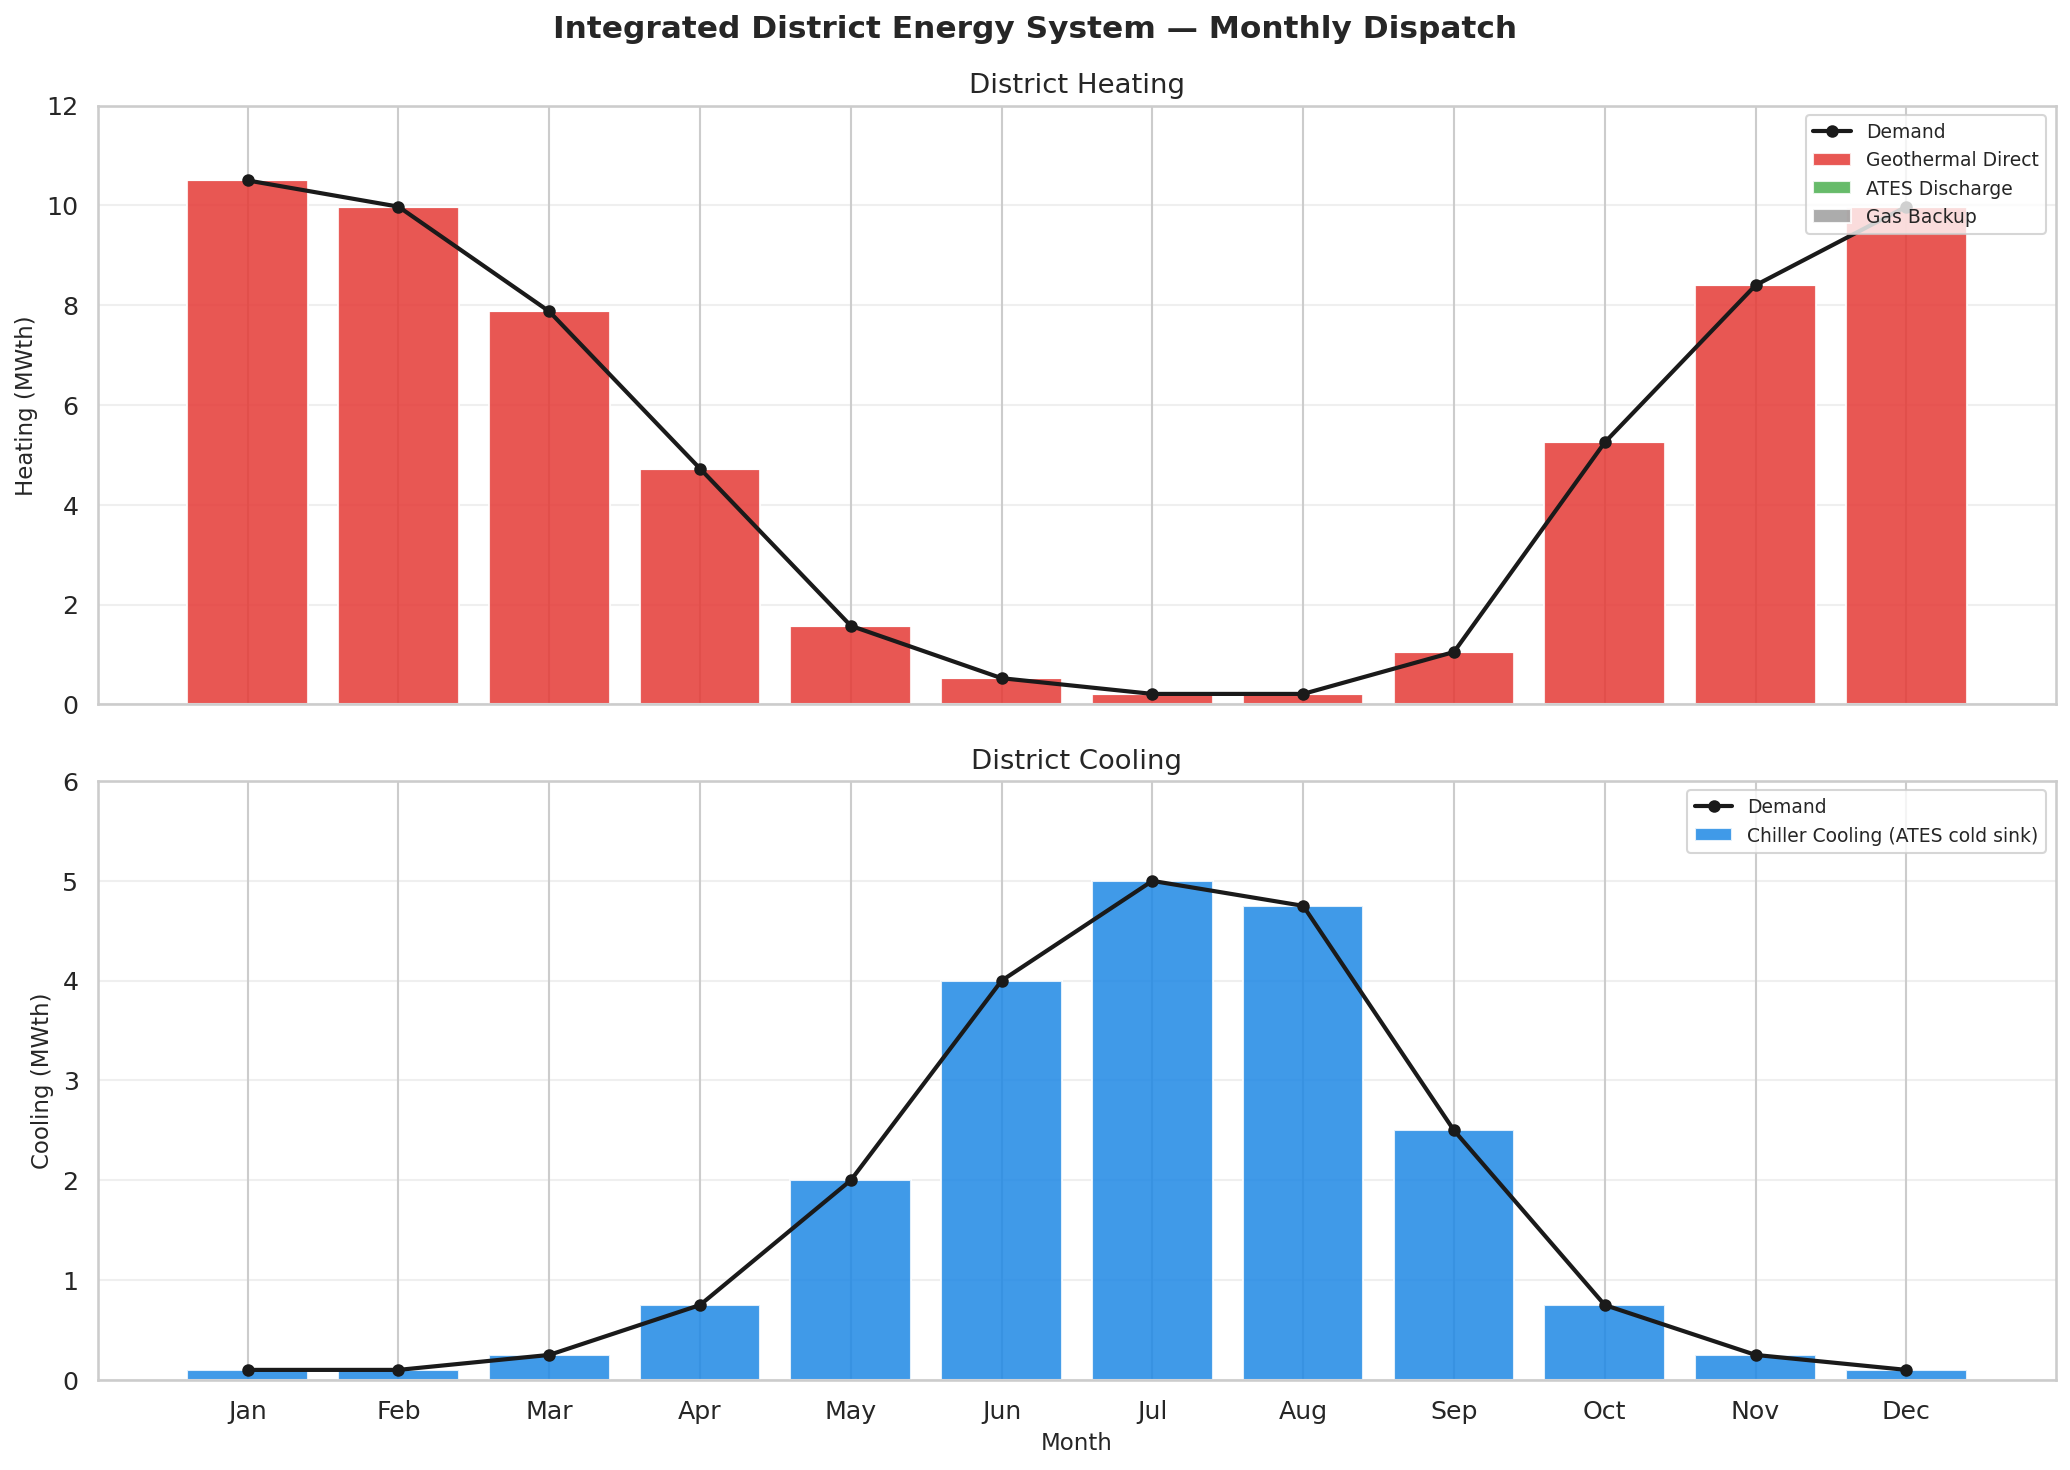

Saved: outputs/figures/integrated_system_dispatch.png


In [12]:
# Stacked dispatch chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Integrated District Energy System — Monthly Dispatch', fontsize=15, fontweight='bold')
x = np.arange(12)

ax1.bar(x, demand_df['Geo_Direct_MW'], label='Geothermal Direct', color='#E53935', alpha=0.85)
ax1.bar(x, demand_df['ATES_Discharge_MW'], bottom=demand_df['Geo_Direct_MW'],
        label='ATES Discharge', color='#4CAF50', alpha=0.85)
ax1.bar(x, demand_df['Backup_MW'],
        bottom=demand_df['Geo_Direct_MW'] + demand_df['ATES_Discharge_MW'],
        label='Gas Backup', color='#9E9E9E', alpha=0.85)
ax1.plot(x, heating_demand, 'ko-', label='Demand', markersize=5, linewidth=2)
ax1.set_ylabel('Heating (MWth)', fontsize=11); ax1.legend(fontsize=9, loc='upper right')
ax1.set_ylim(0, 12); ax1.grid(axis='y', alpha=0.3); ax1.set_title('District Heating')

ax2.bar(x, cooling_demand, label='Chiller Cooling (ATES cold sink)', color='#1E88E5', alpha=0.85)
ax2.plot(x, cooling_demand, 'ko-', label='Demand', markersize=5, linewidth=2)
ax2.set_ylabel('Cooling (MWth)', fontsize=11); ax2.set_xlabel('Month', fontsize=11)
ax2.set_xticks(x); ax2.set_xticklabels(months); ax2.legend(fontsize=9)
ax2.set_ylim(0, 6); ax2.grid(axis='y', alpha=0.3); ax2.set_title('District Cooling')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'integrated_system_dispatch.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: outputs/figures/integrated_system_dispatch.png")


## 11. System Performance Summary

In [13]:
# Performance summary — aligned to Surface Facilities Design Report
performance = pd.DataFrame([
    {'Metric': 'Blended production temperature', 'Value': '73.0', 'Unit': '°C'},
    {'Metric': 'Blended flow rate', 'Value': '300', 'Unit': 'm³/h'},
    {'Metric': 'Gross geothermal power', 'Value': f'{Q_geothermal_MW:.2f}', 'Unit': 'MWth'},
    {'Metric': 'Heat pump upgrade', 'Value': '0.45', 'Unit': 'MWth'},
    {'Metric': 'District heating delivered', 'Value': '10.5', 'Unit': 'MWth'},
    {'Metric': 'District cooling delivered', 'Value': '5.0', 'Unit': 'MWth'},
    {'Metric': 'Cooling flow required', 'Value': '540', 'Unit': 'm³/h'},
    {'Metric': 'Reinjection temperature', 'Value': '37.5', 'Unit': '°C'},
    {'Metric': 'Hot storage', 'Value': '575 / 20', 'Unit': 'm³ / MWh'},
    {'Metric': 'Cold storage', 'Value': '1225 / 10', 'Unit': 'm³ / MWh'},
    {'Metric': 'Solar PV', 'Value': '1.5', 'Unit': 'MW'},
])
performance.to_csv(TABLES_DIR / 'system_performance.csv', index=False)
print("System Performance Summary:")
print(performance.to_string(index=False))

# demand_summary for Notebook 03
demand_summary = pd.DataFrame([
    {'Parameter': 'District Heating Delivered', 'Value': 10.5, 'Unit': 'MWth'},
    {'Parameter': 'District Cooling Delivered', 'Value': 5.0, 'Unit': 'MWth'},
    {'Parameter': 'Blended Production Temp', 'Value': 73.0, 'Unit': '°C'},
    {'Parameter': 'Gross Geothermal Power', 'Value': round(Q_geothermal_MW,2), 'Unit': 'MWth'},
    {'Parameter': 'Heat Pump Upgrade', 'Value': 0.45, 'Unit': 'MWth'},
    {'Parameter': 'Heat Pump Elec', 'Value': 0.2, 'Unit': 'MW'},
    {'Parameter': 'Chiller Elec', 'Value': 1.0, 'Unit': 'MW'},
    {'Parameter': 'Solar PV', 'Value': 1.5, 'Unit': 'MW'},
    {'Parameter': 'Reinjection Temp', 'Value': 37.5, 'Unit': '°C'},
])
demand_summary.to_csv(TABLES_DIR / 'demand_summary.csv', index=False)
print("\nSaved: demand_summary.csv, system_performance.csv")


System Performance Summary:
                        Metric     Value     Unit
Blended production temperature      73.0       °C
             Blended flow rate       300     m³/h
        Gross geothermal power     12.31     MWth
             Heat pump upgrade      0.45     MWth
    District heating delivered      10.5     MWth
    District cooling delivered       5.0     MWth
         Cooling flow required       540     m³/h
       Reinjection temperature      37.5       °C
                   Hot storage  575 / 20 m³ / MWh
                  Cold storage 1225 / 10 m³ / MWh
                      Solar PV       1.5       MW

Saved: demand_summary.csv, system_performance.csv


---
## Summary

Integrated district energy system — matching the Surface Facilities Design Report:

1. **Production blending:** GLA-01 (160 m³/h, 70°C) + BLT-01 (140 m³/h, 77°C) → 300 m³/h blended at 73°C
2. **Gross geothermal power:** 86.67 kg/s × 4.0 kJ/kg·K × (73−37.5) = 12.31 MWth
3. **Titanium plate heat exchanger:** brine 73→37.5°C, district water 40→68°C (hydraulic separation, corrosion resistance)
4. **Heat pump:** upgrades 68→70°C, delivers 0.45 MWth, COP ~2.25, 0.2 MW solar
5. **District heating:** 10.5 MWth at 300 m³/h (70/40°C)
6. **Mechanical chiller + ATES cold well:** 5.0 MWth cooling at 540 m³/h (7/15°C), 1.0 MW
7. **Buffer tanks:** hot 575 m³ (20 MWh, 5 MWth/4h), cold 1225 m³ (10 MWh, 2.5 MWth/4h)
8. **ATES seasonal:** warm 15–35°C, cold 8–15°C
9. **Solar PV:** 1.5 MW supplies heat pump (0.2 MW) + chiller (1.0 MW), 0.3 MW surplus
10. **Reinjection:** 37.5°C maintains reservoir pressure, prevents thermal breakthrough

**Next:** Notebook 03 — Economic Analysis and Uncertainty
